# Aluminium smelting electricity generation mix, 12 scenarios

Self contained. Everything the figure does is in the cells below, so you can edit any label,
position or size directly. No imports from `common.py`.

In [43]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# --- where the runs live ---------------------------------------------------------------
RUNS = Path("../../runs")                                     # limitedCCS and CCS runs
ARCHIVE = Path("../../../_archive/scenarios_92switches")      # the superseded noCCS runs

# --- the 3 x 4 grid --------------------------------------------------------------------
# rows, in order top to bottom: (folder tag, row label)
ROWS = [("noCCS", "No CCS"),
        ("limitedCCS", "Limited CCS"),
        ("CCS", "Unlimited CCS")]

# columns, in order left to right: (grid tag, anode tag, column title)
COLUMNS = [("MPP",  "Locked",   "MPP grid\ninert anode locked"),
           ("SBTi", "Locked",   "SBTi grid\ninert anode locked"),
           ("MPP",  "Unlocked", "MPP grid\ninert anode unlocked"),
           ("SBTi", "Unlocked", "SBTi grid\ninert anode unlocked")]

# --- power source groups and their colours ---------------------------------------------
GROUPS = {"Fossil fuel":              ["Coal", "Natural Gas"],
          "Fossil fuel with capture": ["Coal+CCS", "Natural Gas+CCS"],
          "Grid":                     ["Grid"],
          "Power purchase agreement": ["PPA+Grid"],
          "Hydro":                    ["Hydro"],
          "Nuclear":                  ["Small Modular Reactor"]}

COLOURS = {"Fossil fuel": "#8d8d8d", "Fossil fuel with capture": "#e08e79",
           "Grid": "#f2c14e", "Power purchase agreement": "#c9a227",
           "Hydro": "#8ab6d6", "Nuclear": "#3d6b8c"}

GROUP_ORDER = list(GROUPS)
SOURCE_TO_GROUP = {source: group for group, sources in GROUPS.items() for source in sources}

plt.rcParams.update({"font.family": "sans-serif", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": False})

## Load the twelve runs

In [44]:
def load_mix(capture, grid, anode):
    """Smelter production by power source group and year, Mt aluminium."""
    name = f"LC_{grid}grid_{capture}_Anode{anode}"
    folder = ARCHIVE if capture == "noCCS" else RUNS
    path = glob.glob(str(folder / name / "smelter" / "final" / "interface_outputs_*.csv"))[0]

    df = pd.read_csv(path)
    df = df[(df["technology"] != "All") & (df["parameter"] == "Annual production volume")]

    # technology names are "<anode> + <power source>", so take the part after the separator
    df["group"] = [SOURCE_TO_GROUP[t.split(" + ", 1)[1]] for t in df["technology"]]

    mix = df.pivot_table(index="year", columns="group", values="value", aggfunc="sum")
    mix = mix.reindex(range(2020, 2051)).fillna(0.0)
    for group in GROUP_ORDER:          # keep every group present so colours never shift
        if group not in mix.columns:
            mix[group] = 0.0
    return mix[GROUP_ORDER]


mixes = {(capture, grid, anode): load_mix(capture, grid, anode)
         for capture, _ in ROWS for grid, anode, _ in COLUMNS}

print(f"loaded {len(mixes)} runs")
mixes[("limitedCCS", "MPP", "Unlocked")].loc[[2020, 2035, 2050]].round(1)

loaded 12 runs


group,Fossil fuel,Fossil fuel with capture,Grid,Power purchase agreement,Hydro,Nuclear
year,,,,,,
2020,36.0,0.0,15.9,6.1,7.4,0.0
2035,4.8,2.0,30.0,25.1,6.7,0.0
2050,0.0,4.0,26.1,17.2,6.6,13.6


## The figure

Every number that positions something is in this cell. The three left-hand labels sit at
`x=0.008`, the rotated unit label at `x=0.048`, and `rect` in `tight_layout` reserves the
space they sit in.

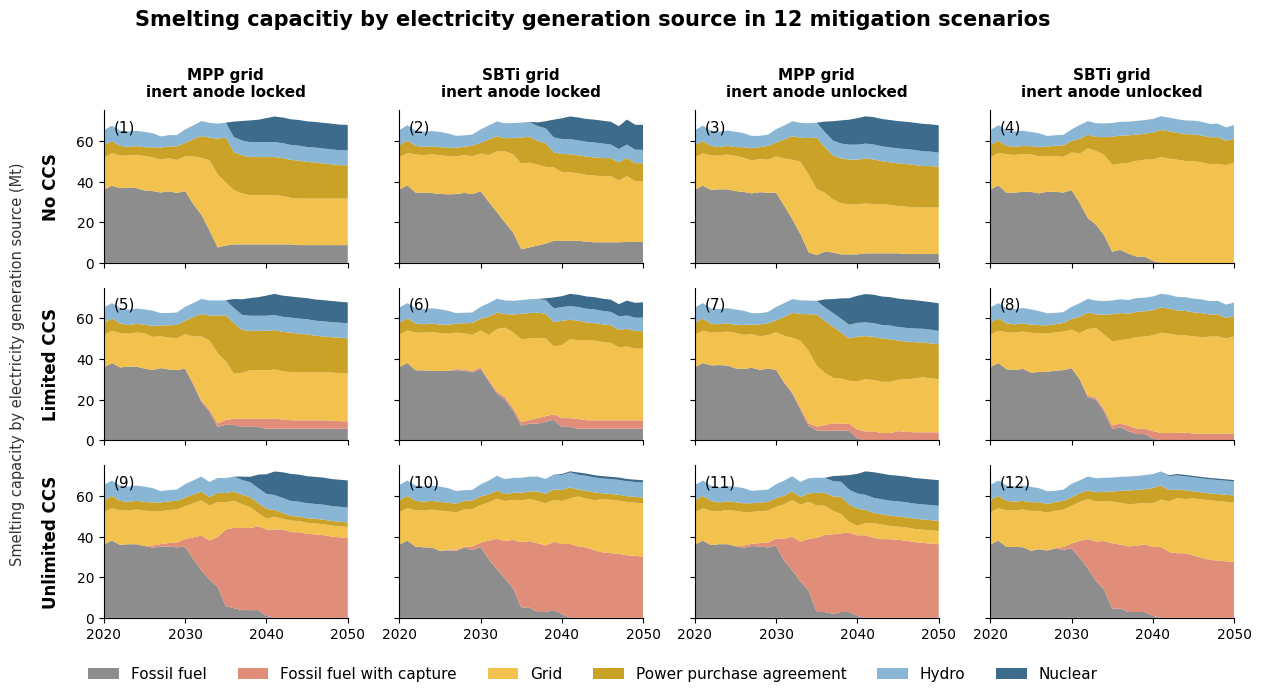

In [45]:
TITLE = "Smelting capacitiy by electricity generation source in 12 mitigation scenarios"
Y_LABEL = "Smelting capacity by electricity generation source (Mt)"

CAPTION = """ """

fig, axes = plt.subplots(len(ROWS), len(COLUMNS), figsize=(13.5, 9.4), sharex=True, sharey=True)

panel_number = 1
for row, (capture, row_label) in enumerate(ROWS):
    for col, (grid, anode, col_title) in enumerate(COLUMNS):
        ax = axes[row, col]
        mix = mixes[(capture, grid, anode)]
        ax.stackplot(mix.index, [mix[g].values for g in GROUP_ORDER],
                     colors=[COLOURS[g] for g in GROUP_ORDER], labels=GROUP_ORDER)
        ax.set_xlim(2020, 2050)
        ax.set_xticks([2020, 2030, 2040, 2050])
        ax.set_ylim(0, 75)
        ax.tick_params(labelsize=10)
        ax.text(0.04, 0.94, f"({panel_number})", transform=ax.transAxes,
                ha="left", va="top", fontsize=11)
        panel_number += 1
        if row == 0:
            ax.set_title(col_title, fontsize=11, fontweight="bold")

fig.suptitle(TITLE, fontsize=15, fontweight="bold", y=0.935)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, 0.205))

# rect leaves room on the left for the two label columns, and at the bottom for legend and caption
fig.tight_layout(rect=[0.105, 0.245, 1, 0.93])
fig.canvas.draw()                       # so get_position below returns the final layout

# left-hand labels: capture regime outboard, unit inboard
for row, (capture, row_label) in enumerate(ROWS):
    box = axes[row, 0].get_position()
    fig.text(0.092, (box.y0 + box.y1) / 2, row_label, rotation=90,
             ha="left", va="center", fontsize=12, fontweight="bold")

top = axes[0, 0].get_position()
bottom = axes[-1, 0].get_position()
fig.text(0.068, (top.y1 + bottom.y0) / 2, Y_LABEL, rotation=90,
         ha="left", va="center", fontsize=10.5, color="#333333")

#fig.text(0.015, 0.012, CAPTION, ha="left", va="bottom", fontsize=9,
        # color="#333333", linespacing=1.6)

for extension in ("png", "svg"):
    fig.savefig(f"../../figures/electricity_generation_mix.{extension}", dpi=200,
                bbox_inches="tight")
plt.show()